In [9]:
import numpy as np
from sklearn.feature_selection import f_classif


def compute_sensor_scores(dataloader):
    """
    Computes ANOVA F-scores per sensor using ONLY training data.
    """

    all_features = []
    all_labels = []

    for x, y, _ in dataloader:

        x = x.numpy()
        y = y.numpy()
        
        sensor_features = x.mean(axis=2)

        all_features.append(sensor_features)
        all_labels.append(y)

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    scores, _ = f_classif(X, y)

    return scores


def get_top_k_sensors(f_scores, top_k=50):
    indices = np.argsort(f_scores)[::-1].copy()
    return indices[:top_k]

In [10]:
class SensorSelector:
    def __init__(self, sensor_indices):
        self.sensor_indices = sensor_indices

    def __call__(self, x):
        return x[self.sensor_indices, :]

In [1]:
import torch

from dataset import create_dataloaders, SensorFilteredDataset
from tcn_model import MEGTCN
from gan_model import MEGGAN
from mlp_model import MLP
from cnn_baseline_1d import CNNBaseline1D
from evaluate import compare_models
from torch.utils.data import ConcatDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [12]:
BATCH_SIZE = 8
INTRA_DATA_DIR = "preprocessed_data/Intra"
intra_train_loader, intra_test_loader = create_dataloaders(INTRA_DATA_DIR, BATCH_SIZE, add_person_id=True)

intra_train_dataset = intra_train_loader.dataset
intra_test_dataset = intra_test_loader.dataset

Loading test data...
Loading train data...
Loaded 32 training samples
Loaded 8 test samples
Class distribution in training: [8 8 8 8]
Class distribution in test: [2 2 2 2]
Train batches: 4
Test batches: 1


In [13]:
scores = compute_sensor_scores(intra_train_loader)

top50 = get_top_k_sensors(scores, 50)
top100 = get_top_k_sensors(scores, 100)
top150 = get_top_k_sensors(scores, 150)
top200 = get_top_k_sensors(scores, 200)

In [14]:
intra_model_configs = [
    {
        "name": "MLP",
        "model_class": MLP,
        "params": {'learning_rate': 0.0005, 'dropout': 0.05, 'hidden_size': 64, 'batch_size': 8},
    },
    {
        "name": "CNN",
        "model_class": CNNBaseline1D,
        "params": {"learning_rate": 1e-3, "kernel_size": 5, "dropout": 0.05, "hidden_channels": 16, "batch_size": 8},
    },
    {
        "name": "TCN",
        "model_class": MEGTCN,
        "params": {'learning_rate': 0.0001, 'kernel_size': 7, 'dropout': 0.05, 'hidden_channels': 64, 'batch_size': 8},
    },
    {
        "name": "GAN",
        "model_class": MEGGAN,
        "params": {'learning_rate': 0.005, 'hidden_channels': 32, 'kernel_size': 3, 'dropout': 0.1, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8},
    },
]

In [16]:
sensor_scenarios = {
    "all": None,
    "top200": top200,
    "top150": top150,
    "top100": top100,
    "top50": top50,
}

intra_results = compare_models(
    intra_model_configs,
    intra_train_dataset,
    intra_test_dataset,
    num_classes=4,
    device=DEVICE,
    sensor_scenarios=sensor_scenarios,
    epochs=20,
    n_runs=5
)


MODEL: MLP

--------------------------------------------------
SENSOR SET: all
--------------------------------------------------
Scenario=all, Sensors=248
Run 1/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 2/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 3/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 4/5 | Acc: 100.00%
Scenario=all, Sensors=248
Run 5/5 | Acc: 100.00%

--------------------------------------------------
SENSOR SET: top200
--------------------------------------------------
Scenario=top200, Sensors=200
Run 1/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 2/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 3/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 4/5 | Acc: 100.00%
Scenario=top200, Sensors=200
Run 5/5 | Acc: 100.00%

--------------------------------------------------
SENSOR SET: top150
--------------------------------------------------
Scenario=top150, Sensors=150
Run 1/5 | Acc: 100.00%
Scenario=top150, Sensors=150
Run 2/5 | Acc: 100.00%
Scenario=top150,

In [17]:
rows = []

for r in intra_results:
    model_name = r["model"]

    for scenario, stats in r["results"].items():
        rows.append({
            "model": model_name,
            "scenario": scenario,
            "acc_mean": stats["acc_mean"],
            "acc_std": stats["acc_std"],
        })

df = pd.DataFrame(rows)

scenarios = df["scenario"].unique()
models = df["model"].unique()

x = np.arange(len(scenarios))
width = 0.8 / len(models)

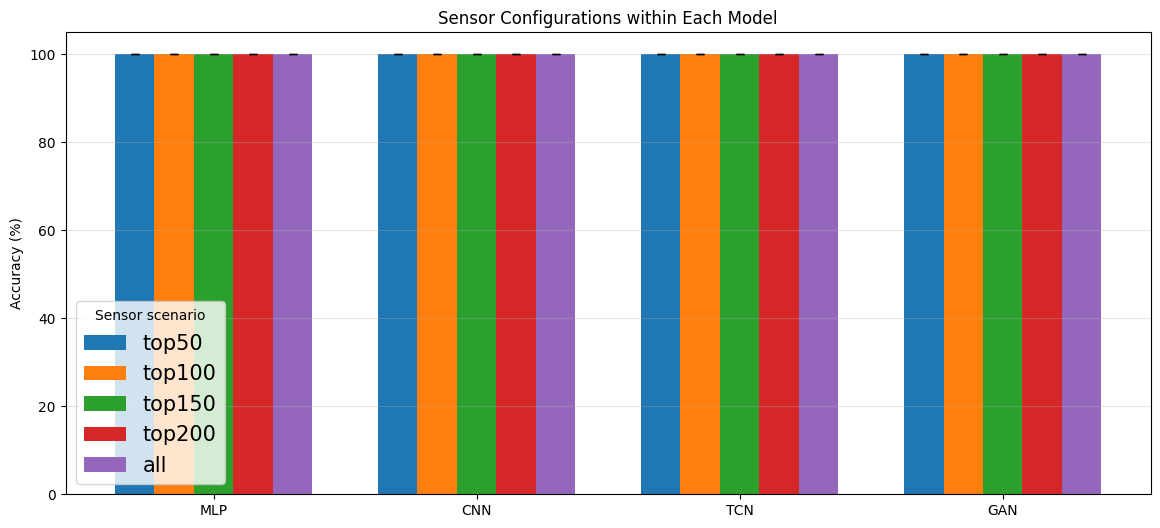

In [18]:
scenario_order = ["top50", "top100", "top150", "top200", "all"]
scenarios = [s for s in scenario_order if s in df["scenario"].unique()]

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(14, 6))

for i, scenario in enumerate(scenarios):
    values = []

    for model in models:
        val = df[
            (df["model"] == model) &
            (df["scenario"] == scenario)
        ]["acc_mean"].values

        values.append(val[0] if len(val) > 0 else 0)

    plt.bar(
        x + i * width,
        values,
        width,
        yerr=[
            df[(df["model"] == m) & (df["scenario"] == scenario)]["acc_std"].values[0]
            if len(df[(df["model"] == m) & (df["scenario"] == scenario)]) > 0
            else 0
            for m in models
        ],
        capsize=3,
        label=scenario
    )

plt.xticks(x + width * (len(scenarios) - 1) / 2, models)
plt.ylabel("Accuracy (%)")
plt.title("Sensor Configurations within Each Model")
plt.legend(title="Sensor scenario", loc='lower left', fontsize = 15)
plt.grid(axis="y", alpha=0.3)

plt.show()

# Compare on cross dataset

In [6]:
import numpy as np
from sklearn.feature_selection import f_classif


def compute_sensor_scores(dataloader):
    """
    Computes ANOVA F-scores per sensor using ONLY training data.
    """

    all_features = []
    all_labels = []

    for x, y, _ in dataloader:

        x = x.numpy()
        y = y.numpy()
        
        sensor_features = x.mean(axis=2)

        all_features.append(sensor_features)
        all_labels.append(y)

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    scores, _ = f_classif(X, y)

    return scores


def get_top_k_sensors(f_scores, top_k=50):
    indices = np.argsort(f_scores)[::-1].copy()
    return indices[:top_k]

In [7]:
class SensorSelector:
    def __init__(self, sensor_indices):
        self.sensor_indices = sensor_indices

    def __call__(self, x):
        return x[self.sensor_indices, :]

In [6]:
BATCH_SIZE = 8
CROSS_DATA_DIR = "preprocessed_data/Cross"
cross_train_loader, cross_test_loader = create_dataloaders(CROSS_DATA_DIR, BATCH_SIZE, add_person_id=True)

combined_train_dataset = ConcatDataset([
    intra_train_loader.dataset,
    cross_train_loader.dataset
])

combined_train_loader = DataLoader(
    combined_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Loading test1 data...
Loading test2 data...
Loading test3 data...
Loading train data...
Loaded 64 training samples
Loaded 48 test samples
Class distribution in training: [16 16 16 16]
Class distribution in test: [12 12 12 12]
Train batches: 8
Test batches: 6


In [ ]:
cross_model_configs = [
    {
        "name": "MLP",
        "model_class": MLP,
        "params": {'learning_rate': 0.0005, 'dropout': 0.05, 'hidden_size': 64, 'batch_size': 8},
        "epochs": 7
    },
    {
        "name": "CNN",
        "model_class": CNNBaseline1D,
        "params": {"learning_rate": 1e-3, "kernel_size": 5, "dropout": 0.05, "hidden_channels": 16, "batch_size": 8},
        "epochs": 29
    },
    {
        "name": "TCN",
        "model_class": MEGTCN,
        "params": {'learning_rate': 0.0001, 'kernel_size': 7, 'dropout': 0.05, 'hidden_channels': 64, 'batch_size': 8},
        "epochs": 25
    },
    {
        "name": "GAN",
        "model_class": MEGGAN,
        "params": {'learning_rate': 0.005, 'hidden_channels': 32, 'kernel_size': 3, 'dropout': 0.1, 'num_heads': 2, 'weight_decay': 0.0001, 'batch_size': 8},
        "epochs": 25
    },
]

In [16]:
scores = compute_sensor_scores(combined_train_loader)

top50 = get_top_k_sensors(scores, 50)
top100 = get_top_k_sensors(scores, 100)
top150 = get_top_k_sensors(scores, 150)
top200 = get_top_k_sensors(scores, 200)

In [17]:
sensor_scenarios = {
    "all": None,
    "top200": top200,
    "top150": top150,
    "top100": top100,
    "top50": top50,
}

results = compare_models(
    model_configs=cross_model_configs,
    train_dataset=combined_train_dataset,
    test_dataset=cross_test_loader.dataset,
    num_classes=4,
    device=DEVICE,
    sensor_scenarios=sensor_scenarios,
    n_runs=25,
)


MODEL: TCN

--------------------------------------------------
SENSOR SET: all
--------------------------------------------------
Scenario=all, Sensors=248
Run 1/25 | Acc: 66.67%
Scenario=all, Sensors=248
Run 2/25 | Acc: 62.50%
Scenario=all, Sensors=248
Run 3/25 | Acc: 62.50%
Scenario=all, Sensors=248
Run 4/25 | Acc: 68.75%
Scenario=all, Sensors=248
Run 5/25 | Acc: 66.67%
Scenario=all, Sensors=248
Run 6/25 | Acc: 68.75%
Scenario=all, Sensors=248
Run 7/25 | Acc: 68.75%
Scenario=all, Sensors=248
Run 8/25 | Acc: 58.33%
Scenario=all, Sensors=248
Run 9/25 | Acc: 66.67%
Scenario=all, Sensors=248
Run 10/25 | Acc: 64.58%
Scenario=all, Sensors=248
Run 11/25 | Acc: 66.67%
Scenario=all, Sensors=248
Run 12/25 | Acc: 56.25%
Scenario=all, Sensors=248
Run 13/25 | Acc: 66.67%
Scenario=all, Sensors=248
Run 14/25 | Acc: 66.67%
Scenario=all, Sensors=248
Run 15/25 | Acc: 58.33%
Scenario=all, Sensors=248
Run 16/25 | Acc: 70.83%
Scenario=all, Sensors=248
Run 17/25 | Acc: 58.33%
Scenario=all, Sensors=248
Ru

In [11]:
rows = []

for r in results:
    model_name = r["model"]

    for scenario, stats in r["results"].items():
        rows.append({
            "model": model_name,
            "scenario": scenario,
            "acc_mean": stats["acc_mean"],
            "acc_std": stats["acc_std"],
        })

df = pd.DataFrame(rows)

scenarios = df["scenario"].unique()
models = df["model"].unique()

x = np.arange(len(scenarios))
width = 0.8 / len(models)

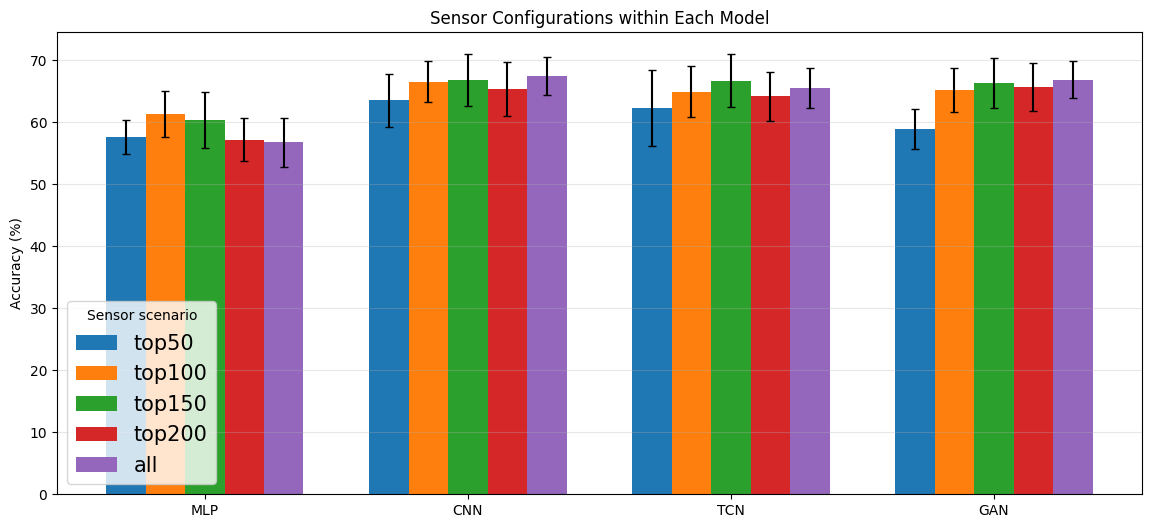

In [15]:
scenario_order = ["top50", "top100", "top150", "top200", "all"]
scenarios = [s for s in scenario_order if s in df["scenario"].unique()]

x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(14, 6))

for i, scenario in enumerate(scenarios):
    values = []

    for model in models:
        val = df[
            (df["model"] == model) &
            (df["scenario"] == scenario)
        ]["acc_mean"].values

        values.append(val[0] if len(val) > 0 else 0)

    plt.bar(
        x + i * width,
        values,
        width,
        yerr=[
            df[(df["model"] == m) & (df["scenario"] == scenario)]["acc_std"].values[0]
            if len(df[(df["model"] == m) & (df["scenario"] == scenario)]) > 0
            else 0
            for m in models
        ],
        capsize=3,
        label=scenario
    )

plt.xticks(x + width * (len(scenarios) - 1) / 2, models)
plt.ylabel("Accuracy (%)")
plt.title("Sensor Configurations within Each Model")
plt.legend(title="Sensor scenario", loc='lower left', fontsize = 15)
plt.grid(axis="y", alpha=0.3)

plt.show()